In [ ]:
# Cell 1 — Install dependencies

# Uncomment only if needed.
!pip install pandas matplotlib

In [ ]:
# Cell 2 — Imports

from pathlib import Path

import pandas as pd

In [ ]:
# Cell 3 — Robust CSV loader

def load_species_data(csv_path):
    """
    Load the species presence dataset from a CSV file.

    Parameters
    ----------
    csv_path : pathlib.Path
        Path to the CSV file.

    Returns
    -------
    pandas.DataFrame
        Loaded species dataframe.
    """
    if not csv_path.exists():
        raise FileNotFoundError(f"File not found: {csv_path}")

    df = pd.read_csv(
        csv_path,
        sep=None,
        engine="python",
        encoding="utf-8-sig",
    )

    df.columns = df.columns.str.strip()

    return df

In [ ]:
# Cell 4 — Define input path

DATA_DIR = Path(
    r"C:\Users\jdelhoyo\PhD\Study cases\Genissiat"
    r"\RV Characterization\repo-github\data"
)

SPECIES_PATH = DATA_DIR / "species.csv"

print(SPECIES_PATH)

C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\species.csv


In [ ]:
# Cell 5 — Load species dataset

df_species = load_species_data(SPECIES_PATH)

print("Shape:", df_species.shape)
display(df_species.head())

Shape: (88, 39)


,Id_Data,Id_Place,Id_RipUnit,Id_Reach,Basin,Sub_Basin,Stand_Code,Bank,Cod_Plg,RipUnit,...,sp_20,sp_21,sp_22,sp_23,sp_24,sp_25,sp_26,sp_27,sp_28,sp_29
0,1,1,1,1,Arve,Arve,A-A1,Left,A-A1-Left,A-A1-Left,...,0,0,0,1,0,0,0,0,0,0
1,2,1,2,1,Arve,Arve,A-A1,Right,A-A1-Right,A-A1-Right,...,0,0,0,0,0,0,0,0,0,0
2,3,2,3,2,Arve,Arve,A-A2,Left,A-A2-Left,A-A2-Left,...,0,1,0,0,0,0,0,0,0,0
3,4,2,4,2,Arve,Arve,A-A2,Right,A-A2-Right,A-A2-Right,...,0,1,0,0,0,0,0,0,0,0
4,5,3,5,3,Arve,Arve,A-A3,Left,A-A3-Left,A-A3-Left,...,0,1,0,0,0,1,0,1,0,0


In [ ]:
# Cell 6 — Inspect columns

print("Columns:")
for column in df_species.columns:
    print(column)

Columns:
Id_Data
Id_Place
Id_RipUnit
Id_Reach
Basin
Sub_Basin
Stand_Code
Bank
Cod_Plg
RipUnit
sp_1
sp_2
sp_3
sp_4
sp_5
sp_6
sp_7
sp_8
sp_9
sp_10
sp_11
sp_12
sp_13
sp_14
sp_15
sp_16
sp_17
sp_18
sp_19
sp_20
sp_21
sp_22
sp_23
sp_24
sp_25
sp_26
sp_27
sp_28
sp_29


In [ ]:
# Cell 7 — Inspect species columns

species_columns = [
    column
    for column in df_species.columns
    if column.startswith("sp_")
]

print("Number of species columns:", len(species_columns))
print(species_columns)

display(df_species[species_columns].head())

Number of species columns: 29
['sp_1', 'sp_2', 'sp_3', 'sp_4', 'sp_5', 'sp_6', 'sp_7', 'sp_8', 'sp_9', 'sp_10', 'sp_11', 'sp_12', 'sp_13', 'sp_14', 'sp_15', 'sp_16', 'sp_17', 'sp_18', 'sp_19', 'sp_20', 'sp_21', 'sp_22', 'sp_23', 'sp_24', 'sp_25', 'sp_26', 'sp_27', 'sp_28', 'sp_29']


,sp_1,sp_2,sp_3,sp_4,sp_5,sp_6,sp_7,sp_8,sp_9,sp_10,...,sp_20,sp_21,sp_22,sp_23,sp_24,sp_25,sp_26,sp_27,sp_28,sp_29
0,1,0,1,1,1,0,0,0,0,1,...,0,0,0,1,0,0,0,0,0,0
1,0,0,1,1,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,0,1,1,1,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
3,0,1,1,1,0,0,0,0,1,0,...,0,1,0,0,0,0,0,0,0,0
4,0,1,0,0,1,0,0,0,0,0,...,0,1,0,0,0,1,0,1,0,0


In [ ]:
# Cell 8 — Basic structural checks

required_columns = [
    "Id_Data",
    "Id_Place",
    "Id_RipUnit",
    "Id_Reach",
    "Basin",
    "Sub_Basin",
    "Stand_Code",
    "Bank",
]

missing_columns = [
    column
    for column in required_columns
    if column not in df_species.columns
]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

if len(species_columns) == 0:
    raise ValueError("No species columns found with prefix 'sp_'.")

print("Basic checks passed.")

Basic checks passed.


In [ ]:
# Cell 9 — Updated tree grouping

TREE_SPECIES_TO_GROUP = {
    2: "Populus",
    3: "Salix",
    4: "Alnus",
    5: "Fraxinus",
    6: "Fagus",
    8: "Quercus",
    9: "Ulmus",
    15: "Acer",
    1: "Abies",
    10: "Larix",
    11: "Pinus",
    12: "Picea",
    7: "Other trees",
    13: "Other trees",
    16: "Other trees",
    18: "Other trees",
    19: "Other trees",
    22: "Other trees",
    25: "Other trees",
}

GROUP_ORDER = [
    "Populus",
    "Salix",
    "Alnus",
    "Fraxinus",
    "Fagus",
    "Quercus",
    "Ulmus",
    "Acer",
    "Abies",
    "Larix",
    "Pinus",
    "Picea",
    "Other trees",
]

In [ ]:
# Cell 10 — Build reach-level tree-species presence ordered by Id_Place

def build_reach_species_presence(
    df,
    species_to_group,
    grouping_column="Stand_Code",
    order_column="Id_Place",
    sp_prefix="sp_",
):
    """
    Aggregate species presence at reach level and order reaches numerically.

    Presence is calculated at species level before grouping. If a species is
    present in either Left or Right bank, it is considered present in the
    reach.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe with binary species columns.
    species_to_group : dict
        Dictionary mapping species numeric IDs to plotting groups.
    grouping_column : str
        Column defining the reach.
    order_column : str
        Numeric column used to order reaches.
    sp_prefix : str
        Prefix used in species columns.

    Returns
    -------
    pandas.DataFrame
        Binary species presence table aggregated by reach.
    list
        Ordered reach names.
    """
    species_ids = list(species_to_group.keys())

    species_columns = [
        f"{sp_prefix}{species_id}"
        for species_id in species_ids
        if f"{sp_prefix}{species_id}" in df.columns
    ]

    if not species_columns:
        raise ValueError("No matching tree-species columns were found.")

    if grouping_column not in df.columns:
        raise ValueError(f"Column not found: {grouping_column}")

    if order_column not in df.columns:
        raise ValueError(f"Column not found: {order_column}")

    df_work = df.copy()

    df_work[order_column] = pd.to_numeric(
        df_work[order_column],
        errors="coerce",
    )

    if df_work[order_column].isna().any():
        raise ValueError(
            f"Some values in {order_column} could not be converted "
            "to numeric."
        )

    for column in species_columns:
        df_work[column] = df_work[column].fillna(0).astype(int)

    reach_order_table = (
        df_work[[grouping_column, order_column]]
        .groupby(grouping_column, sort=False, as_index=False)
        .agg({order_column: "min"})
        .sort_values(order_column)
    )

    reach_order = reach_order_table[grouping_column].tolist()

    reach_species_presence = (
        df_work
        .groupby(grouping_column, sort=False)[species_columns]
        .max()
        .reindex(reach_order)
    )

    return reach_species_presence, reach_order

In [ ]:
# Cell 11 — Convert species presence into grouped counts

def build_grouped_species_counts(
    reach_species_presence,
    species_to_group,
    group_order,
    sp_prefix="sp_",
):
    """
    Sum species presences into plotting groups.

    Conifers are counted as the number of conifer species present.
    Other trees are counted as the number of other tree species present.

    Parameters
    ----------
    reach_species_presence : pandas.DataFrame
        Binary species presence table aggregated by reach.
    species_to_group : dict
        Dictionary mapping species numeric IDs to plotting groups.
    group_order : list of str
        Desired plotting order.
    sp_prefix : str
        Prefix used in species columns.

    Returns
    -------
    pandas.DataFrame
        Grouped species-presence counts by reach.
    """
    grouped_counts = pd.DataFrame(index=reach_species_presence.index)

    for group_name in group_order:
        species_ids = [
            species_id
            for species_id, group in species_to_group.items()
            if group == group_name
        ]

        columns = [
            f"{sp_prefix}{species_id}"
            for species_id in species_ids
            if f"{sp_prefix}{species_id}" in reach_species_presence.columns
        ]

        if columns:
            grouped_counts[group_name] = reach_species_presence[columns].sum(
                axis=1
            )
        else:
            grouped_counts[group_name] = 0

    return grouped_counts

In [ ]:
# Cell 12 — Updated plotting function

def plot_tree_species_composition(
    frequencies,
    n_rows,
    total_presences,
    output_path=None,
):
    """
    Plot a 100% stacked bar chart of tree-species composition.

    Parameters
    ----------
    frequencies : pandas.DataFrame
        Relative frequencies in percent.
    n_rows : pandas.Series
        Number of original rows per reach.
    total_presences : pandas.Series
        Total number of tree species present per reach.
    output_path : pathlib.Path or None
        Optional output path.

    Returns
    -------
    matplotlib.figure.Figure
        Generated figure.
    """
    fig_width = max(10, 0.35 * len(frequencies))
    fig, ax = plt.subplots(figsize=(fig_width, 6))

    bottom = pd.Series(0.0, index=frequencies.index)

    colors = {
        "Populus": "white",
        "Salix": "white",
        "Alnus": "white",
        "Fraxinus": "white",
        "Fagus": "white",
        "Quercus": "white",
        "Ulmus": "white",
        "Acer": "white",
        "Abies": "0.15",
        "Larix": "0.15",
        "Pinus": "0.15",
        "Picea": "0.15",
        "Other trees": "white",
    }

    hatches = {
        "Populus": "////",
        "Salix": "\\\\\\\\",
        "Alnus": "||||",
        "Fraxinus": "---",
        "Fagus": "++",
        "Quercus": "xx",
        "Ulmus": "..",
        "Acer": "oo",
        "Abies": "",
        "Larix": "///",
        "Pinus": "\\\\\\",
        "Picea": "xxx",
        "Other trees": "...",
    }

    for column in frequencies.columns:
        ax.bar(
            frequencies.index,
            frequencies[column],
            bottom=bottom,
            label=column,
            color=colors.get(column, "white"),
            edgecolor="black",
            linewidth=0.8,
            hatch=hatches.get(column, ""),
        )
        bottom = bottom + frequencies[column]

    ax.set_ylabel("Relative frequency of tree presences [%]")
    ax.set_xlabel("Reach")
    ax.set_ylim(0, 108)
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.set_yticklabels(["0%", "25%", "50%", "75%", "100%"])

    ax.tick_params(axis="x", rotation=90)

    for idx, reach in enumerate(frequencies.index):
        ax.text(
            idx,
            102,
            f"n={int(n_rows.loc[reach])}\nocc={int(total_presences.loc[reach])}",
            ha="center",
            va="bottom",
            fontsize=7,
        )

    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.28),
        ncol=4,
        frameon=False,
    )

    fig.tight_layout()

    if output_path is not None:
        fig.savefig(output_path, dpi=300, bbox_inches="tight")

    return fig

In [ ]:
# Cell 12a — Editable species style

SPECIES_STYLE = {
    # Broadleaved species: white or very light background
    "Populus": {
        "facecolor": "white",
        "hatch": "////",
        "alpha": 1.0,
    },
    "Salix": {
        "facecolor": "white",
        "hatch": "\\\\\\\\",
        "alpha": 1.0,
    },
    "Alnus": {
        "facecolor": "white",
        "hatch": "||||",
        "alpha": 1.0,
    },
    "Fraxinus": {
        "facecolor": "white",
        "hatch": "---",
        "alpha": 1.0,
    },
    "Fagus": {
        "facecolor": "white",
        "hatch": "++",
        "alpha": 1.0,
    },
    "Quercus": {
        "facecolor": "white",
        "hatch": "xx",
        "alpha": 1.0,
    },
    "Ulmus": {
        "facecolor": "white",
        "hatch": "..",
        "alpha": 1.0,
    },
    "Acer": {
        "facecolor": "white",
        "hatch": "oo",
        "alpha": 1.0,
    },

    # Conifers: same grey background, different hatches
    "Abies": {
        "facecolor": "0.65",
        "hatch": "",
        "alpha": 1.0,
    },
    "Larix": {
        "facecolor": "0.65",
        "hatch": "///",
        "alpha": 1.0,
    },
    "Pinus": {
        "facecolor": "0.65",
        "hatch": "\\\\\\",
        "alpha": 1.0,
    },
    "Picea": {
        "facecolor": "0.65",
        "hatch": "xxx",
        "alpha": 1.0,
    },

    # Remaining low-frequency broadleaved trees
    "Other trees": {
        "facecolor": "white",
        "hatch": "...",
        "alpha": 1.0,
    },
}

In [ ]:
# Cell 12b — Plot stacked bar chart with separated legend axis

import math


def reorder_legend_items_rowwise(handles, labels, ncol):
    """
    Reorder legend items so Matplotlib displays them row by row.

    Matplotlib internally fills legends by columns. This helper reorders
    handles and labels so the visual legend order reads left to right.
    """
    n_items = len(labels)
    n_rows = math.ceil(n_items / ncol)

    grid = [[None for _ in range(ncol)] for _ in range(n_rows)]

    item_index = 0
    for row in range(n_rows):
        for col in range(ncol):
            if item_index < n_items:
                grid[row][col] = item_index
                item_index += 1

    reordered_indices = []
    for col in range(ncol):
        for row in range(n_rows):
            if grid[row][col] is not None:
                reordered_indices.append(grid[row][col])

    reordered_handles = [handles[index] for index in reordered_indices]
    reordered_labels = [labels[index] for index in reordered_indices]

    return reordered_handles, reordered_labels


def plot_tree_species_composition(
    frequencies,
    species_style,
    output_path=None,
):
    """
    Plot a 100% stacked bar chart of taxa composition by reach.

    Parameters
    ----------
    frequencies : pandas.DataFrame
        Relative frequencies in percent.
    species_style : dict
        Dictionary defining facecolor, hatch, and alpha for each group.
    output_path : pathlib.Path or None
        Optional output path.

    Returns
    -------
    matplotlib.figure.Figure
        Generated figure.
    """
    n_reaches = len(frequencies.index)

    fig_width = max(18, 0.34 * n_reaches)
    fig_height = 8.6

    fig, (ax, legend_ax) = plt.subplots(
        2,
        1,
        figsize=(fig_width, fig_height),
        gridspec_kw={
            "height_ratios": [5.6, 1.25],
            "hspace": 0.12,
        },
    )

    legend_ax.axis("off")

    x_positions = list(range(n_reaches))
    bar_width = 0.98

    bottom = pd.Series(0.0, index=frequencies.index)

    for column in frequencies.columns:
        style = species_style.get(
            column,
            {
                "facecolor": "white",
                "hatch": "",
                "alpha": 1.0,
            },
        )

        ax.bar(
            x_positions,
            frequencies[column].values,
            width=bar_width,
            bottom=bottom.values,
            label=column,
            color=style["facecolor"],
            edgecolor="black",
            linewidth=0.8,
            hatch=style["hatch"],
            alpha=style["alpha"],
            align="center",
        )

        bottom = bottom + frequencies[column]

    ax.set_ylabel(
        "Relative frequency of taxa occurrence [%]",
        fontsize=20,
        labelpad=12,
    )

    # The x-axis label is intentionally removed to avoid overlap.
    ax.set_xlabel("")

    ax.set_ylim(0, 100)
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.set_yticklabels(
        ["0%", "25%", "50%", "75%", "100%"],
        fontsize=18,
    )

    ax.set_xticks(x_positions)
    ax.set_xticklabels(
        frequencies.index,
        rotation=90,
        fontsize=15,
    )

    ax.set_xlim(-0.5, n_reaches - 0.5)
    ax.margins(x=0)

    handles, labels = ax.get_legend_handles_labels()

    ncol = 7
    handles, labels = reorder_legend_items_rowwise(
        handles=handles,
        labels=labels,
        ncol=ncol,
    )

    legend_ax.legend(
        handles,
        labels,
        loc="center",
        bbox_to_anchor=(0.0, 0.0, 1.0, 1.0),
        mode="expand",
        ncol=ncol,
        frameon=False,
        fontsize=18,
        handlelength=1.8,
        handleheight=1.25,
        handletextpad=0.55,
        columnspacing=1.2,
        labelspacing=0.8,
        borderaxespad=0.0,
    )

    fig.subplots_adjust(
        left=0.095,
        right=0.995,
        top=0.985,
        bottom=0.055,
    )

    if output_path is not None:
        fig.savefig(
            output_path,
            dpi=300,
            bbox_inches="tight",
            pad_inches=0.05,
        )

    return fig

In [ ]:
# Cell 13 — Rebuild reach-level presence ordered by Id_Place

reach_species_presence, reach_order = build_reach_species_presence(
    df=df_species,
    species_to_group=TREE_SPECIES_TO_GROUP,
    grouping_column="Stand_Code",
    order_column="Id_Place",
)

order_check = (
    df_species[["Stand_Code", "Id_Place"]]
    .assign(Id_Place=lambda x: pd.to_numeric(x["Id_Place"]))
    .groupby("Stand_Code", sort=False, as_index=False)
    .agg({"Id_Place": "min"})
    .sort_values("Id_Place")
)

display(order_check)
display(reach_species_presence.head())

,Stand_Code,Id_Place
0,A-A1,1
1,A-A2,2
2,A-A3,3
3,A-A4,4
4,A-A5,5
5,A-A6,6
6,A-A7,7
7,A-A8,8
8,A-A9,9
9,A-A10,10


,sp_2,sp_3,sp_4,sp_5,sp_6,sp_8,sp_9,sp_15,sp_1,sp_10,sp_11,sp_12,sp_7,sp_13,sp_16,sp_18,sp_19,sp_22,sp_25
Stand_Code,,,,,,,,,,,,,,,,,,,
A-A1,0,1,1,1,0,0,0,1,1,1,0,1,1,0,0,0,0,0,0
A-A2,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,0
A-A3,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1
A-A4,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
A-A5,1,1,0,1,0,1,0,1,1,1,0,1,0,0,0,0,1,0,0


In [ ]:
# Cell 14 — Rebuild grouped counts and frequencies

grouped_counts = build_grouped_species_counts(
    reach_species_presence=reach_species_presence,
    species_to_group=TREE_SPECIES_TO_GROUP,
    group_order=GROUP_ORDER,
)

frequencies, total_presences = calculate_relative_frequencies(
    grouped_counts
)

n_rows = (
    df_species
    .groupby("Stand_Code", sort=False)
    .size()
    .reindex(reach_order)
)

display(grouped_counts)
display(frequencies.round(1))

,Populus,Salix,Alnus,Fraxinus,Fagus,Quercus,Ulmus,Acer,Abies,Larix,Pinus,Picea,Other trees
Stand_Code,,,,,,,,,,,,,
A-A1,0,1,1,1,0,0,0,1,1,1,0,1,1
A-A2,1,1,1,0,0,0,1,0,0,0,0,0,2
A-A3,1,0,0,1,0,0,0,0,0,0,0,0,2
A-A4,1,1,1,0,0,0,0,0,0,0,0,0,1
A-A5,1,1,0,1,0,1,0,1,1,1,0,1,1
A-A6,1,1,0,1,1,1,0,1,0,0,1,1,1
A-A7,1,1,0,1,0,1,1,1,0,1,1,1,3
A-A8,1,1,0,1,0,1,1,1,0,0,1,1,3
A-A9,1,1,0,0,0,0,1,1,0,0,0,0,3


,Populus,Salix,Alnus,Fraxinus,Fagus,Quercus,Ulmus,Acer,Abies,Larix,Pinus,Picea,Other trees
Stand_Code,,,,,,,,,,,,,
A-A1,0.0,12.5,12.5,12.5,0.0,0.0,0.0,12.5,12.5,12.5,0.0,12.5,12.5
A-A2,16.7,16.7,16.7,0.0,0.0,0.0,16.7,0.0,0.0,0.0,0.0,0.0,33.3
A-A3,25.0,0.0,0.0,25.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,50.0
A-A4,25.0,25.0,25.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.0
A-A5,11.1,11.1,0.0,11.1,0.0,11.1,0.0,11.1,11.1,11.1,0.0,11.1,11.1
A-A6,11.1,11.1,0.0,11.1,11.1,11.1,0.0,11.1,0.0,0.0,11.1,11.1,11.1
A-A7,8.3,8.3,0.0,8.3,0.0,8.3,8.3,8.3,0.0,8.3,8.3,8.3,25.0
A-A8,9.1,9.1,0.0,9.1,0.0,9.1,9.1,9.1,0.0,0.0,9.1,9.1,27.3
A-A9,14.3,14.3,0.0,0.0,0.0,0.0,14.3,14.3,0.0,0.0,0.0,0.0,42.9


In [ ]:
# Cell 14b — Check missing reaches

all_reaches = pd.Index(
    df_species["Stand_Code"].drop_duplicates(),
    name="Stand_Code",
)

plotted_reaches = pd.Index(
    frequencies.index,
    name="Stand_Code",
)

missing_reaches = all_reaches.difference(plotted_reaches)
extra_reaches = plotted_reaches.difference(all_reaches)

print("Number of reaches in original data:", len(all_reaches))
print("Number of reaches in plot table:", len(plotted_reaches))
print("Missing reaches:", list(missing_reaches))
print("Extra reaches:", list(extra_reaches))

zero_tree_reaches = total_presences[total_presences == 0]

print("Reaches with zero tree species:", list(zero_tree_reaches.index))

Number of reaches in original data: 44
Number of reaches in plot table: 44
Missing reaches: []
Extra reaches: []
Reaches with zero tree species: []


In [ ]:
# Cell 14c — Rank individual tree species by presence frequency

TREE_SPECIES_METADATA = {
    1: {"Species": "Abies", "Current_Group": "Conifers"},
    2: {"Species": "Populus", "Current_Group": "Populus"},
    3: {"Species": "Salix", "Current_Group": "Salix"},
    4: {"Species": "Alnus", "Current_Group": "Alnus"},
    5: {"Species": "Fraxinus", "Current_Group": "Fraxinus"},
    6: {"Species": "Fagus", "Current_Group": "Fagus"},
    7: {"Species": "Sorbus", "Current_Group": "Other trees"},
    8: {"Species": "Quercus", "Current_Group": "Other trees"},
    9: {"Species": "Ulmus", "Current_Group": "Other trees"},
    10: {"Species": "Larix", "Current_Group": "Conifers"},
    11: {"Species": "Pinus", "Current_Group": "Conifers"},
    12: {"Species": "Picea", "Current_Group": "Conifers"},
    13: {"Species": "Prunus", "Current_Group": "Other trees"},
    15: {"Species": "Acer", "Current_Group": "Other trees"},
    16: {"Species": "Castanea", "Current_Group": "Other trees"},
    18: {"Species": "Tilia", "Current_Group": "Other trees"},
    19: {"Species": "Robinia", "Current_Group": "Other trees"},
    22: {"Species": "Aesculus", "Current_Group": "Other trees"},
    25: {"Species": "Juglans", "Current_Group": "Other trees"},
}

species_frequency_rows = []

for sp_number, metadata in TREE_SPECIES_METADATA.items():
    column = f"sp_{sp_number}"

    if column not in df_species.columns:
        species_frequency_rows.append(
            {
                "SP_Number": sp_number,
                "Species": metadata["Species"],
                "Current_Group": metadata["Current_Group"],
                "Presence_Count": None,
                "Column_Found": False,
            }
        )
        continue

    count = (
        df_species[column]
        .fillna(0)
        .astype(int)
        .sum()
    )

    species_frequency_rows.append(
        {
            "SP_Number": sp_number,
            "Species": metadata["Species"],
            "Current_Group": metadata["Current_Group"],
            "Presence_Count": int(count),
            "Column_Found": True,
        }
    )

species_frequency_df = (
    pd.DataFrame(species_frequency_rows)
    .sort_values(
        by=["Presence_Count", "Species"],
        ascending=[False, True],
        na_position="last",
    )
    .reset_index(drop=True)
)

display(species_frequency_df)

,SP_Number,Species,Current_Group,Presence_Count,Column_Found
0,5,Fraxinus,Fraxinus,62,True
1,2,Populus,Populus,54,True
2,4,Alnus,Alnus,51,True
3,15,Acer,Other trees,49,True
4,3,Salix,Salix,48,True
5,6,Fagus,Fagus,43,True
6,1,Abies,Conifers,24,True
7,12,Picea,Conifers,23,True
8,9,Ulmus,Other trees,22,True
9,8,Quercus,Other trees,18,True


In [ ]:
# Cell 14e — Audit whether Acer was excluded from previous grouping

acer_column = "sp_15"

if acer_column not in df_species.columns:
    raise ValueError("Column sp_15 was not found in df_species.")

acer_row_count = (
    df_species[acer_column]
    .fillna(0)
    .astype(int)
    .sum()
)

acer_reach_count = (
    df_species
    .assign(**{acer_column: df_species[acer_column].fillna(0).astype(int)})
    .groupby("Stand_Code", sort=False)[acer_column]
    .max()
    .sum()
)

acer_in_current_grouping = (
    "TREE_SPECIES_TO_GROUP" in globals()
    and 15 in TREE_SPECIES_TO_GROUP
)

print("Acer row-level presence count:", int(acer_row_count))
print("Acer reach-level presence count:", int(acer_reach_count))
print("Acer included in current TREE_SPECIES_TO_GROUP:",
      acer_in_current_grouping)

Acer row-level presence count: 49
Acer reach-level presence count: 33
Acer included in current TREE_SPECIES_TO_GROUP: True


In [ ]:
# Cell X — Required plotting imports

import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
# Cell 14b — Rename plotting label before figure generation

RENAME_GROUPS_FOR_PLOT = {
    "Other trees": "Others",
}

frequencies_plot = frequencies.rename(columns=RENAME_GROUPS_FOR_PLOT)
grouped_counts_plot = grouped_counts.rename(columns=RENAME_GROUPS_FOR_PLOT)

SPECIES_STYLE_PLOT = {
    RENAME_GROUPS_FOR_PLOT.get(group_name, group_name): style
    for group_name, style in SPECIES_STYLE.items()
}

display(frequencies_plot.round(1))

,Populus,Salix,Alnus,Fraxinus,Fagus,Quercus,Ulmus,Acer,Abies,Larix,Pinus,Picea,Others
Stand_Code,,,,,,,,,,,,,
A-A1,0.0,12.5,12.5,12.5,0.0,0.0,0.0,12.5,12.5,12.5,0.0,12.5,12.5
A-A2,16.7,16.7,16.7,0.0,0.0,0.0,16.7,0.0,0.0,0.0,0.0,0.0,33.3
A-A3,25.0,0.0,0.0,25.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,50.0
A-A4,25.0,25.0,25.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.0
A-A5,11.1,11.1,0.0,11.1,0.0,11.1,0.0,11.1,11.1,11.1,0.0,11.1,11.1
A-A6,11.1,11.1,0.0,11.1,11.1,11.1,0.0,11.1,0.0,0.0,11.1,11.1,11.1
A-A7,8.3,8.3,0.0,8.3,0.0,8.3,8.3,8.3,0.0,8.3,8.3,8.3,25.0
A-A8,9.1,9.1,0.0,9.1,0.0,9.1,9.1,9.1,0.0,0.0,9.1,9.1,27.3
A-A9,14.3,14.3,0.0,0.0,0.0,0.0,14.3,14.3,0.0,0.0,0.0,0.0,42.9


In [ ]:
# Cell 14c — Botanical labels for the plot legend

BOTANICAL_LABELS = {
    "Populus": r"$\it{Populus}$ spp.",
    "Salix": r"$\it{Salix}$ spp.",
    "Alnus": r"$\it{Alnus}$ spp.",
    "Fraxinus": r"$\it{Fraxinus}$ spp.",
    "Fagus": r"$\it{Fagus}$ spp.",
    "Quercus": r"$\it{Quercus}$ spp.",
    "Ulmus": r"$\it{Ulmus}$ spp.",
    "Acer": r"$\it{Acer}$ spp.",
    "Abies": r"$\it{Abies}$ spp.",
    "Larix": r"$\it{Larix}$ spp.",
    "Pinus": r"$\it{Pinus}$ spp.",
    "Picea": r"$\it{Picea}$ spp.",
    "Others": "Others",
}

frequencies_plot_botanical = frequencies_plot.rename(
    columns=BOTANICAL_LABELS
)

SPECIES_STYLE_PLOT_BOTANICAL = {
    BOTANICAL_LABELS.get(group_name, group_name): style
    for group_name, style in SPECIES_STYLE_PLOT.items()
}

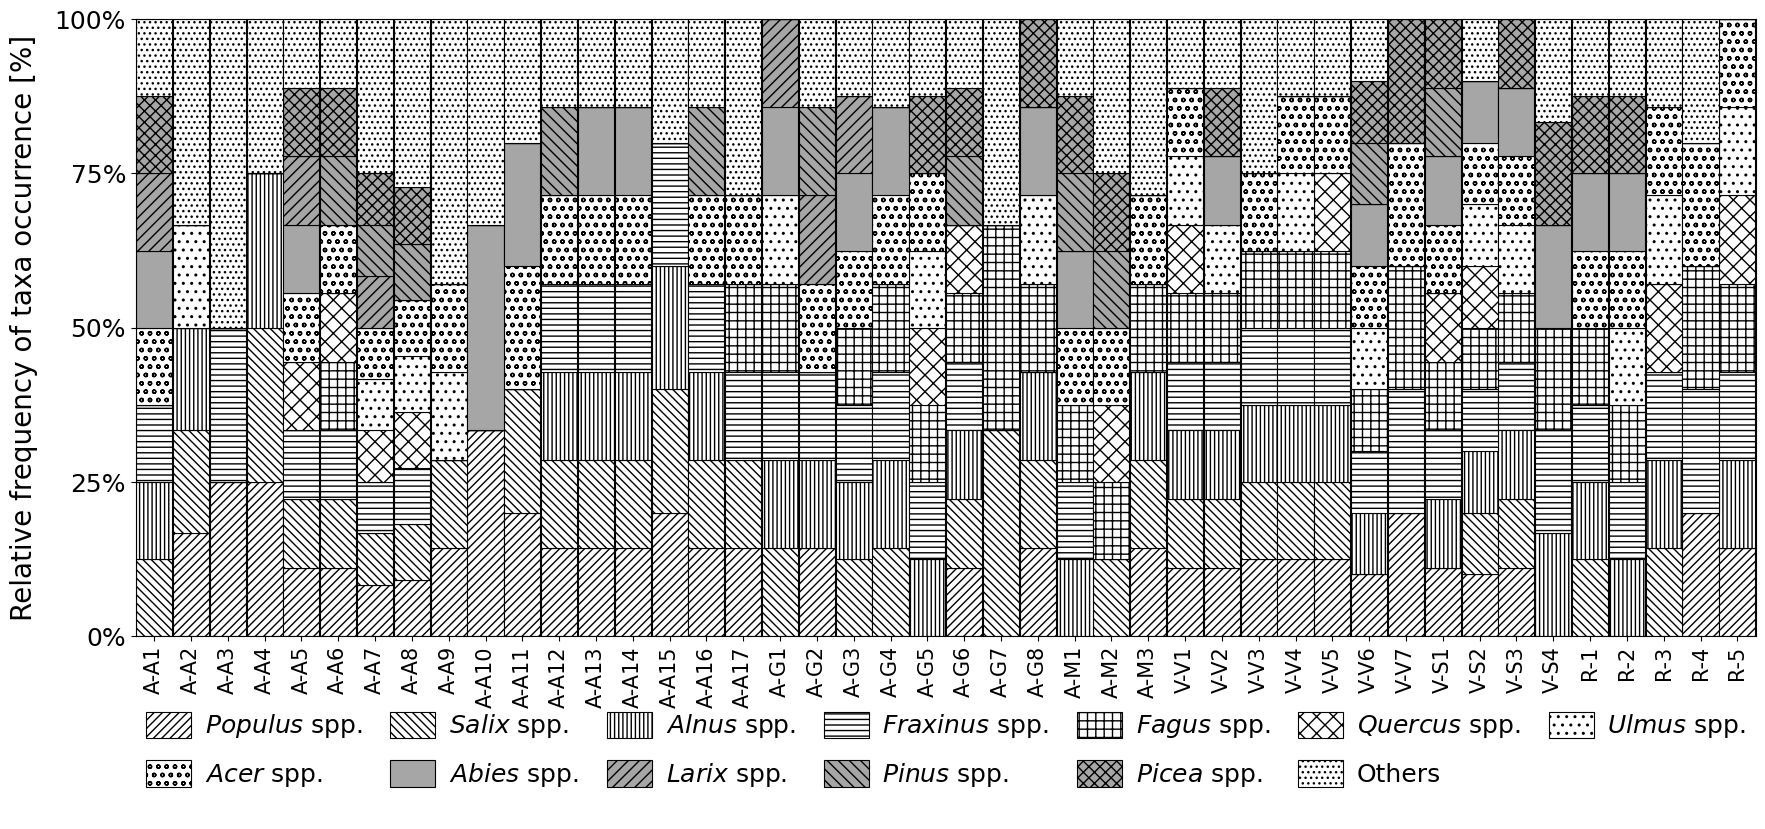

Saved: C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\tree_species_composition_by_reach_final.png


In [ ]:
# Cell 15 — Plot updated figure

output_path = DATA_DIR / "tree_species_composition_by_reach_final.png"

fig = plot_tree_species_composition(
    frequencies=frequencies_plot_botanical,
    species_style=SPECIES_STYLE_PLOT_BOTANICAL,
    output_path=output_path,
)

plt.show()

print("Saved:", output_path)